# Hate Speech Detection — Text Classification with RNN / LSTM

**Student Name :** Amresh Kumar Yadav  
**Student ID   :** 2418108
**Module       :** 6CS012 — Artificial Intelligence and Machine Learning  
**Assessment   :** Final Portfolio — Part III (Language Tasks)

---

## Objective
Classify tweets into one of three classes: **`hate speech`**, **`offensive language`**, or **`neither`**, using three deep-learning architectures and compare their performance.

## Pipeline Overview
1. Load and explore the raw data (EDA).
2. Clean text (lowercase, strip URLs/mentions, expand contractions, lemmatise; **retain hashtag text**).
3. Tokenise → integer-encode → percentile-based padding.
4. Build three models:
   - **Model 1** — Simple RNN with a trainable embedding layer.
   - **Model 2** — Bidirectional LSTM with a trainable embedding layer.
   - **Model 3** — Bidirectional LSTM with **pretrained GloVe-Twitter** embeddings.
5. Train with `class_weight`, `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`.
6. Evaluate (Accuracy, Confusion Matrix, Classification Report, Macro / Weighted F1).
7. Error analysis on Model 3.
8. Real-time Gradio GUI for live predictions.

## Key Improvements over the Baseline Notebook
- **Pretrained GloVe-Twitter** (twitter-domain embeddings) replace self-trained Word2Vec → richer semantics for short, noisy tweets.
- **Bidirectional LSTM** captures both past *and* future context.
- **SpatialDropout1D** + **recurrent dropout** regularise the embedding/recurrent layers more effectively than plain Dropout.
- **ReduceLROnPlateau** callback for finer convergence.
- **Hashtag text retained** (only the `#` symbol is stripped) — addresses an error pattern observed in the baseline.
- **Per-model training time** is recorded for the efficiency analysis.
- **Stratified split** + **class-weighted loss** to handle the heavy class imbalance.

## 1. Environment Setup

> **Note:** if running in Google Colab, uncomment the `pip install` block to install `gensim`, `wordcloud`, `contractions`, and `gradio`. The `numpy==1.23.5` pin is required for `gensim` compatibility.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
!pip install -q numpy==1.23.5
!pip install -q gensim wordcloud nltk contractions gradio seaborn

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [18]:
import os, re, time, pickle, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Bidirectional,
                                     Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)

for pkg in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow :', tf.__version__)
print('GPU avail. :', bool(tf.config.list_physical_devices('GPU')))
print('All imports successful.')

TensorFlow : 2.20.0
GPU avail. : False
All imports successful.


## 2. Load Dataset

Path resolution is automatic — the cell tries the local path first and falls back to the Google Drive path used during Colab development.

In [19]:
CANDIDATE_PATHS = [
    '/content/drive/MyDrive/AI & ML/Assignment/Part 3/Part3/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv'
]

# Ensure we iterate over a list, not a string
file_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

if file_path is None:
    raise FileNotFoundError('CSV not found — check if Drive is mounted and the path is correct.')

df = pd.read_csv(file_path)
print(f'Loaded from : {file_path}')
print(f'Shape       : {df.shape}')
df.head()

Loaded from : /content/drive/MyDrive/AI & ML/Assignment/Part 3/Part3/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv
Shape       : (24783, 2)


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## 3. Exploratory Data Analysis

In [20]:
print('Columns           :', df.columns.tolist())
print('Null values       :', df.isnull().sum().to_dict())
print('Duplicate rows    :', df.duplicated().sum())
print('\nLabel distribution:')
print(df['label'].value_counts())
print('\nLabel proportion (%):')
print((df['label'].value_counts(normalize=True) * 100).round(2))

df = df.drop_duplicates(subset=['text']).dropna(subset=['text']).reset_index(drop=True)
print(f'\nAfter dedup/null-drop: {df.shape}')

Columns           : ['label', 'text']
Null values       : {'label': 0, 'text': 0}
Duplicate rows    : 0

Label distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

Label proportion (%):
label
offensive language    77.43
neither               16.80
hate speec             5.77
Name: proportion, dtype: float64

After dedup/null-drop: (24783, 2)


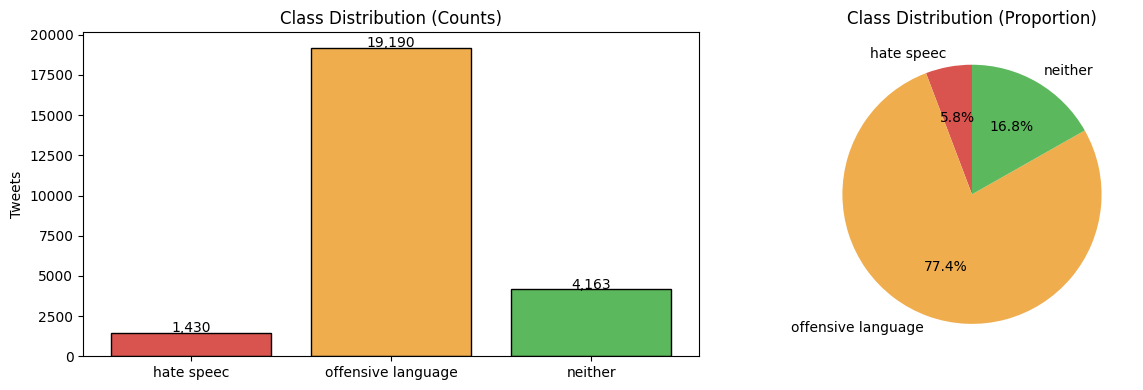

Observation: dataset is heavily imbalanced — `offensive language` dominates,
`hate speec` is the rarest class. We address this with class_weight.


In [21]:
# Fixing typo in label map based on actual dataset values ('hate speec')
label_map = {'hate speec': 0, 'offensive language': 1, 'neither': 2}
df['label_num'] = df['label'].map(label_map)
label_names = ['hate speec', 'offensive language', 'neither']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = df['label'].value_counts().reindex(label_names)

# Handle the plot
axes[0].bar(counts.index, counts.values,
            color=['#d9534f', '#f0ad4e', '#5cb85c'], edgecolor='black')
axes[0].set_title('Class Distribution (Counts)')
for i, v in enumerate(counts.values):
    if not np.isnan(v):
        axes[0].text(i, v + 50, f'{int(v):,}', ha='center', fontsize=10)
axes[0].set_ylabel('Tweets')

# Fix: ensure we drop NaNs before passing to pie chart to avoid the float NaN error
clean_counts = counts.dropna()
axes[1].pie(clean_counts.values, labels=clean_counts.index, autopct='%1.1f%%',
            colors=['#d9534f', '#f0ad4e', '#5cb85c'], startangle=90)
axes[1].set_title('Class Distribution (Proportion)')
plt.tight_layout(); plt.show()

print('Observation: dataset is heavily imbalanced — `offensive language` dominates,')
print('`hate speec` is the rarest class. We address this with class_weight.')

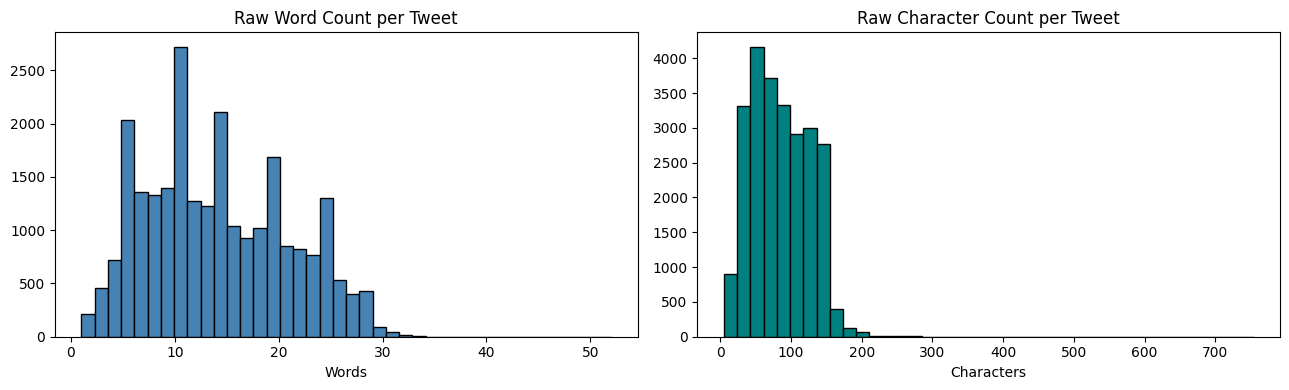

       raw_word_count  raw_char_count
count         24783.0         24783.0
mean             14.1            85.4
std               6.8            41.5
min               1.0             5.0
25%               9.0            52.0
50%              13.0            81.0
75%              19.0           119.0
max              52.0           754.0


In [22]:
df['raw_word_count'] = df['text'].str.split().str.len()
df['raw_char_count'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['raw_word_count'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Raw Word Count per Tweet'); axes[0].set_xlabel('Words')
axes[1].hist(df['raw_char_count'], bins=40, color='teal', edgecolor='black')
axes[1].set_title('Raw Character Count per Tweet'); axes[1].set_xlabel('Characters')
plt.tight_layout(); plt.show()

print(df[['raw_word_count', 'raw_char_count']].describe().round(1))

## 4. Text Cleaning Pipeline

Steps:
1. Lowercase
2. Strip URLs and `@mentions`
3. **Strip the `#` symbol but keep the hashtag word** (e.g. `#racist` → `racist`)
4. Remove digits
5. Expand contractions (`don't` → `do not`)
6. Strip remaining punctuation / non-word chars
7. Collapse whitespace
8. Remove stopwords + lemmatise tokens of length > 1

In [23]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

URL_RE     = re.compile(r'http\S+|www\S+')
MENTION_RE = re.compile(r'@\w+')
HASH_RE    = re.compile(r'#')           # keep the word, drop only the symbol
DIGIT_RE   = re.compile(r'\d+')
PUNCT_RE   = re.compile(r'[^\w\s]')
WS_RE      = re.compile(r'\s+')
RT_RE      = re.compile(r'\brt\b')      # remove standalone retweet marker

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = URL_RE.sub('', text)
    text = MENTION_RE.sub('', text)
    text = HASH_RE.sub('', text)
    text = contractions.fix(text)
    text = DIGIT_RE.sub('', text)
    text = PUNCT_RE.sub(' ', text)
    text = RT_RE.sub('', text)
    text = WS_RE.sub(' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print('=== Before vs After Cleaning ===')
for i in range(3):
    print(f'\n[Sample {i+1}]')
    print('  Raw     :', df['text'].iloc[i][:120])
    print('  Cleaned :', df['cleaned_text'].iloc[i][:120])
print(f'\nFinal dataset shape: {df.shape}')

=== Before vs After Cleaning ===

[Sample 1]
  Raw     : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always t
  Cleaned : woman complain cleaning house amp man always take trash

[Sample 2]
  Raw     : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
  Cleaned : boy dat cold tyga dwn bad cuffin dat hoe st place

[Sample 3]
  Raw     : !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
  Cleaned : dawg ever fuck bitch start cry confused shit

Final dataset shape: (24781, 6)


### 4a. Word Cloud — All Classes

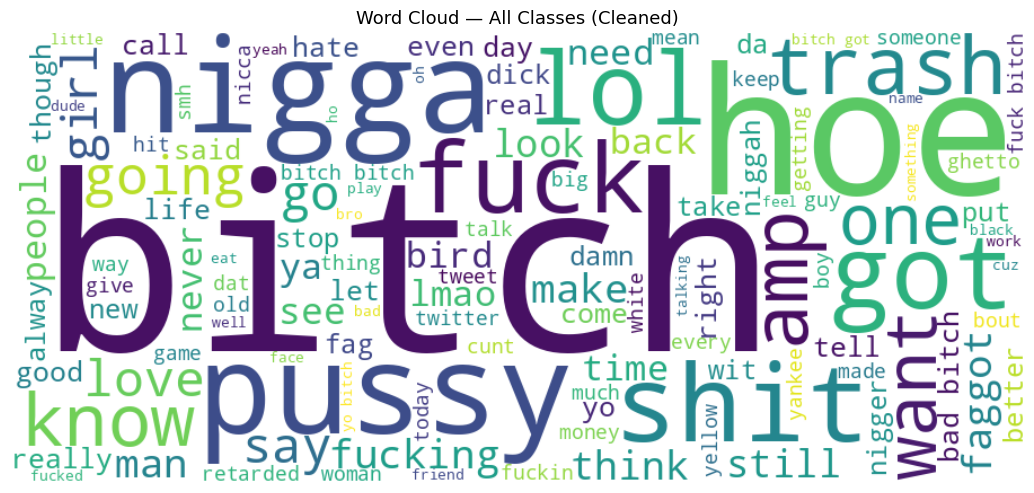

In [24]:
wc = WordCloud(width=900, height=400, background_color='white',
               colormap='viridis', max_words=120).generate(' '.join(df['cleaned_text']))
plt.figure(figsize=(11, 5))
plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
plt.title('Word Cloud — All Classes (Cleaned)', fontsize=13)
plt.tight_layout(); plt.show()

### 4b. Per-Class Word Clouds

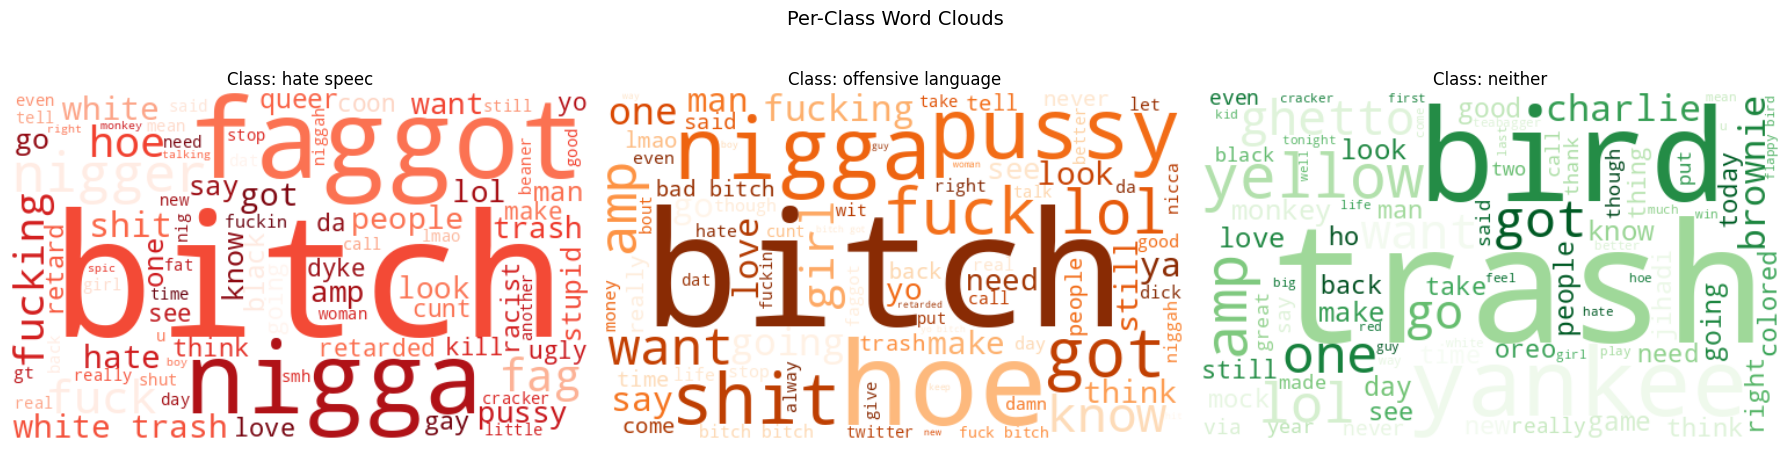

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lbl, cmap in zip(axes, label_names, ['Reds', 'Oranges', 'Greens']):
    sub = ' '.join(df[df['label'] == lbl]['cleaned_text'])
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(sub)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(f'Class: {lbl}', fontsize=12)
plt.suptitle('Per-Class Word Clouds', fontsize=14)
plt.tight_layout(); plt.show()

### 4c. Top-30 Most Frequent Tokens

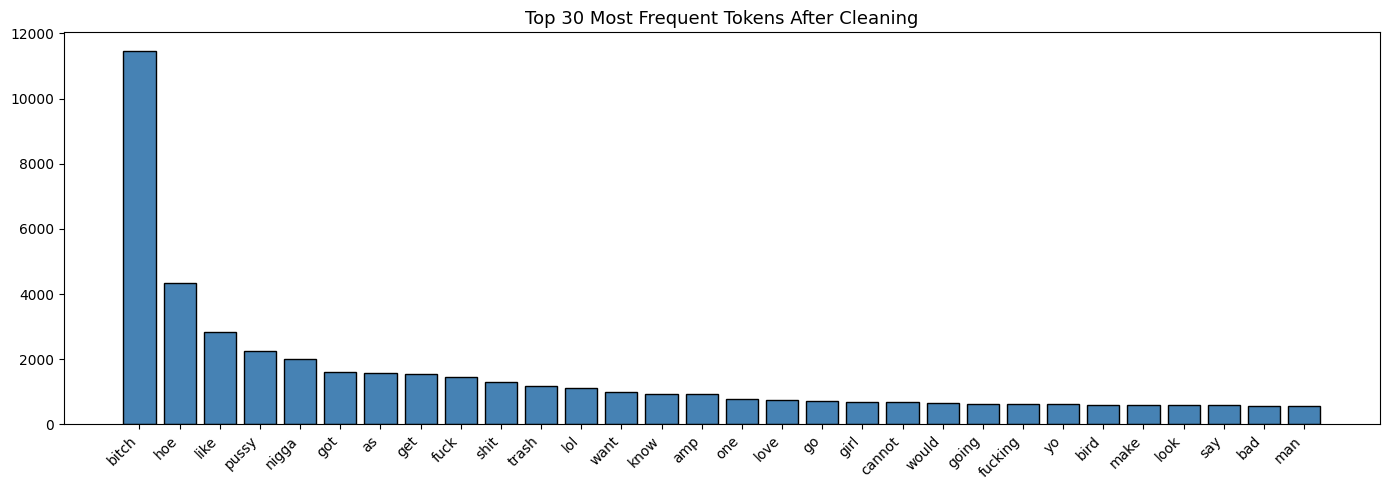

In [26]:
tokens = ' '.join(df['cleaned_text']).split()
freq = Counter(tokens).most_common(30)
words, counts = zip(*freq)

plt.figure(figsize=(14, 5))
plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.title('Top 30 Most Frequent Tokens After Cleaning', fontsize=13)
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 5. Tokenisation, Percentile Padding, Train/Test Split

In [27]:
X = df['cleaned_text'].values
y = df['label_num'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train size : {len(X_train):,}  |  Test size : {len(X_test):,}')

VOCAB_SIZE = 15000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

train_lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(train_lengths, 95))
print(f'\nSequence length — min {min(train_lengths)}, '
      f'mean {np.mean(train_lengths):.1f}, max {max(train_lengths)}, '
      f'95th pct {MAX_LEN} ← used as MAX_LEN')

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f'X_train_pad shape : {X_train_pad.shape}')
print(f'X_test_pad  shape : {X_test_pad.shape}')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('\nTokenizer saved → tokenizer.pkl')

Train size : 19,824  |  Test size : 4,957

Sequence length — min 1, mean 7.2, max 27, 95th pct 14 ← used as MAX_LEN
X_train_pad shape : (19824, 14)
X_test_pad  shape : (4957, 14)

Tokenizer saved → tokenizer.pkl


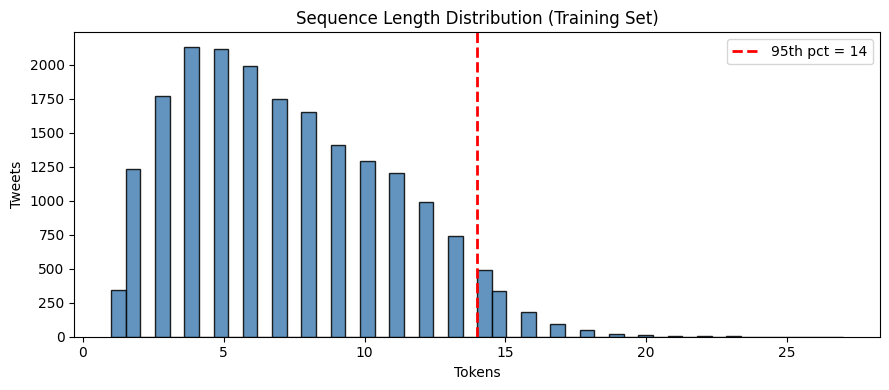

In [28]:
plt.figure(figsize=(9, 4))
plt.hist(train_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.85)
plt.axvline(MAX_LEN, color='red', ls='--', lw=2, label=f'95th pct = {MAX_LEN}')
plt.title('Sequence Length Distribution (Training Set)')
plt.xlabel('Tokens'); plt.ylabel('Tweets'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Class-Weighted Loss

We assign higher loss weight to under-represented classes so the model pays attention to `hate speech` despite its low frequency.

In [29]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print('Class weights:', {label_names[k]: round(v, 3) for k, v in class_weight_dict.items()})

Class weights: {'hate speec': np.float64(5.776), 'offensive language': np.float64(0.43), 'neither': np.float64(1.985)}


## 7. Model Definitions

| # | Architecture | Embedding | Recurrent layer | Regularisation |
|---|--------------|-----------|-----------------|----------------|
| 1 | Simple RNN   | Trainable, dim 128 | `SimpleRNN(64)` | Dropout 0.4 |
| 2 | Bi-LSTM      | Trainable, dim 128 | `Bi-LSTM(64)`   | SpatialDropout 0.3 + recurrent_dropout 0.2 |
| 3 | Bi-LSTM + GloVe | Pretrained GloVe-Twitter (frozen → fine-tune) | `Bi-LSTM(64)` | SpatialDropout 0.3 + recurrent_dropout 0.2 |

### 7.1 Model 1 — Simple RNN

In [30]:
EMBED_DIM = 128

model1 = Sequential(name='SimpleRNN_Model', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 7.2 Model 2 — Bidirectional LSTM

In [31]:
model2 = Sequential(name='BiLSTM_Model', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 7.3 Model 3 — Bi-LSTM with Pretrained GloVe-Twitter Embeddings

We use **`glove-twitter-100`** because it was trained on tweets and therefore covers the slang, abbreviations, and noisy spellings typical of this dataset much better than generic Wikipedia/News embeddings.

In [32]:
import gensim.downloader as api

EMBED_DIM_GLOVE = 100
print('Loading glove-twitter-100 (≈ 200 MB; cached after first run)...')
glove = api.load('glove-twitter-100')
print(f'GloVe vocab size: {len(glove):,}')

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_GLOVE))
covered = missing = 0
for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove:
        embedding_matrix[idx] = glove[word]; covered += 1
    else:
        embedding_matrix[idx] = np.random.normal(0, 0.05, EMBED_DIM_GLOVE)
        missing += 1
print(f'Coverage: {covered:,} covered / {missing:,} OOV '
      f'({covered / (covered + missing) * 100:.1f}%)')

model3 = Sequential(name='BiLSTM_GloVe_Model', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM_GLOVE,
              weights=[embedding_matrix], input_length=MAX_LEN,
              trainable=True),                  # fine-tune
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
model3.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model3.summary()

Loading glove-twitter-100 (≈ 200 MB; cached after first run)...
[==================================================] 100.0% 387.1/387.1MB downloaded
GloVe vocab size: 1,193,514
Coverage: 13,305 covered / 1,694 OOV (88.7%)


Model: "BiLSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,000 (5.72 MB)

 Trainable params: 1,500,000 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Training

Common callbacks:
- `EarlyStopping(patience=4, restore_best_weights=True)` — stop if val loss plateaus.
- `ReduceLROnPlateau(factor=0.5, patience=2)` — halve LR when val loss stagnates.
- `ModelCheckpoint(save_best_only=True)` — keep the best epoch on disk.

In [33]:
def make_callbacks(model_name: str):
    return [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                          min_lr=1e-5, verbose=1),
        ModelCheckpoint(f'{model_name}_best.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

EPOCHS, BATCH = 25, 64
train_times = {}

def train(model, name):
    print(f'\n──── Training {name} ────')
    t0 = time.time()
    hist = model.fit(
        X_train_pad, y_train,
        epochs=EPOCHS, batch_size=BATCH,
        validation_split=0.15,
        class_weight=class_weight_dict,
        callbacks=make_callbacks(name),
        verbose=1
    )
    train_times[name] = time.time() - t0
    print(f'{name} training time: {train_times[name]:.1f}s')
    return hist

In [34]:
history1 = train(model1, 'model1')


──── Training model1 ────
Epoch 1/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6928 - loss: 0.7997 - val_accuracy: 0.7942 - val_loss: 0.5634 - learning_rate: 0.0010
Epoch 2/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8443 - loss: 0.4120 - val_accuracy: 0.7088 - val_loss: 0.6835 - learning_rate: 0.0010
Epoch 3/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9067 - loss: 0.2198 - val_accuracy: 0.7949 - val_loss: 0.5598 - learning_rate: 0.0010
Epoch 4/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9457 - loss: 0.1359 - val_accuracy: 0.7966 - val_loss: 0.5883 - learning_rate: 0.0010
Epoch 5/25
263/264 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9543 - loss: 0.1005
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9573 - loss: 0.0915 - val_accuracy: 0.8161 - val_loss: 0.5671 - learning_rate: 0.0010
Epoch 6/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step -

In [35]:
history2 = train(model2, 'model2')


──── Training model2 ────
Epoch 1/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.7430 - loss: 0.7545 - val_accuracy: 0.8087 - val_loss: 0.5961 - learning_rate: 0.0010
Epoch 2/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.8378 - loss: 0.4137 - val_accuracy: 0.8225 - val_loss: 0.4862 - learning_rate: 0.0010
Epoch 3/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.8773 - loss: 0.2825 - val_accuracy: 0.8262 - val_loss: 0.5106 - learning_rate: 0.0010
Epoch 4/25
263/264 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9085 - loss: 0.2078
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - accuracy: 0.9118 - loss: 0.2054 - val_accuracy: 0.8299 - val_loss: 0.5050 - learning_rate: 0.0010
Epoch 5/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 0.9335 - loss: 0.1412 - val_accuracy: 0.8191 - val_loss: 0.5855 - learning_rate: 5.0000e-04
Epoch 6/25
263/264 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms

In [36]:
history3 = train(model3, 'model3')


──── Training model3 ────
Epoch 1/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.7252 - loss: 0.7508 - val_accuracy: 0.8302 - val_loss: 0.5296 - learning_rate: 0.0010
Epoch 2/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.8086 - loss: 0.5117 - val_accuracy: 0.8322 - val_loss: 0.4695 - learning_rate: 0.0010
Epoch 3/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.8332 - loss: 0.4256 - val_accuracy: 0.8436 - val_loss: 0.4299 - learning_rate: 0.0010
Epoch 4/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.8382 - loss: 0.3753 - val_accuracy: 0.8289 - val_loss: 0.4485 - learning_rate: 0.0010
Epoch 5/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.8526 - loss: 0.3299 - val_accuracy: 0.8413 - val_loss: 0.4193 - learning_rate: 0.0010
Epoch 6/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.8662 - loss: 0.2927 - val_accuracy: 0.8574 - val_loss: 0.4012 - learning_rate: 0.0010
Epoch 7/25
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/

## 9. Training Curves

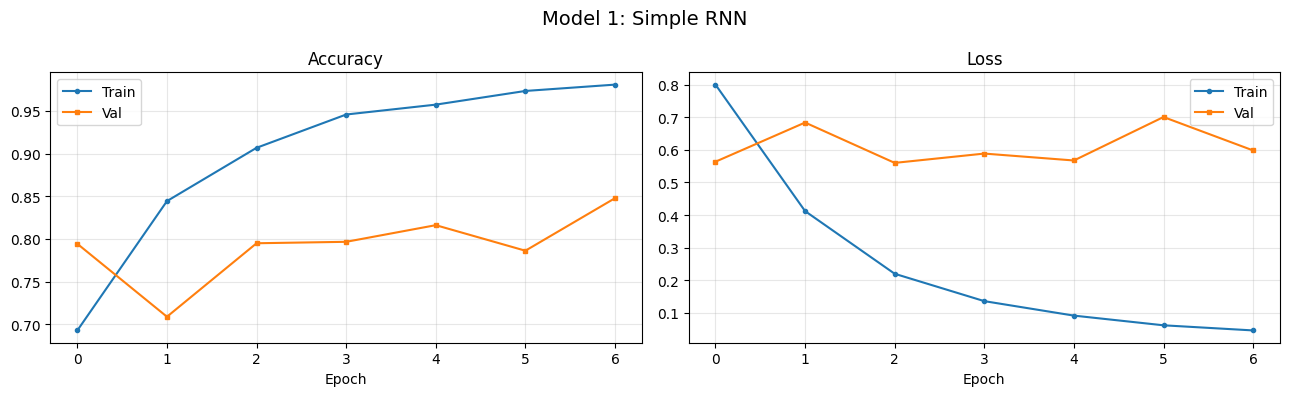

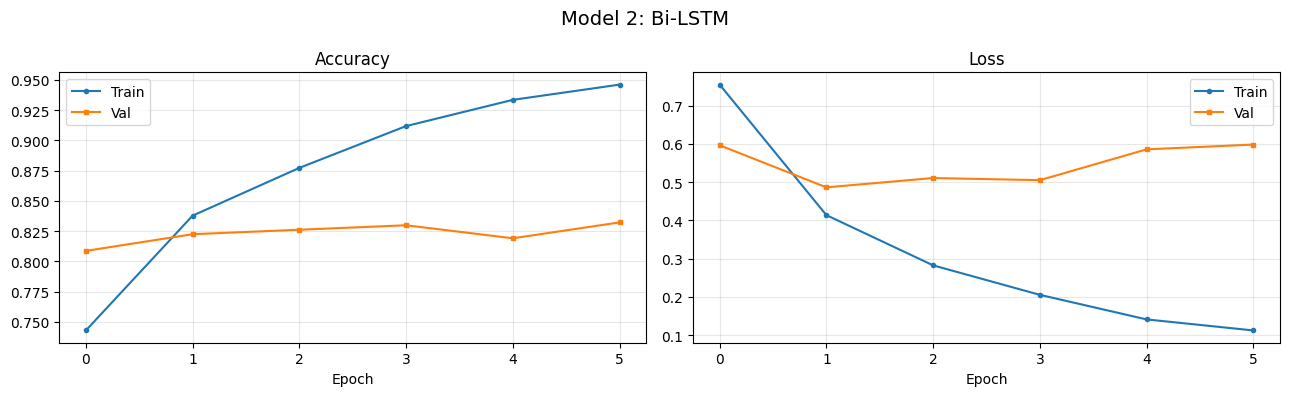

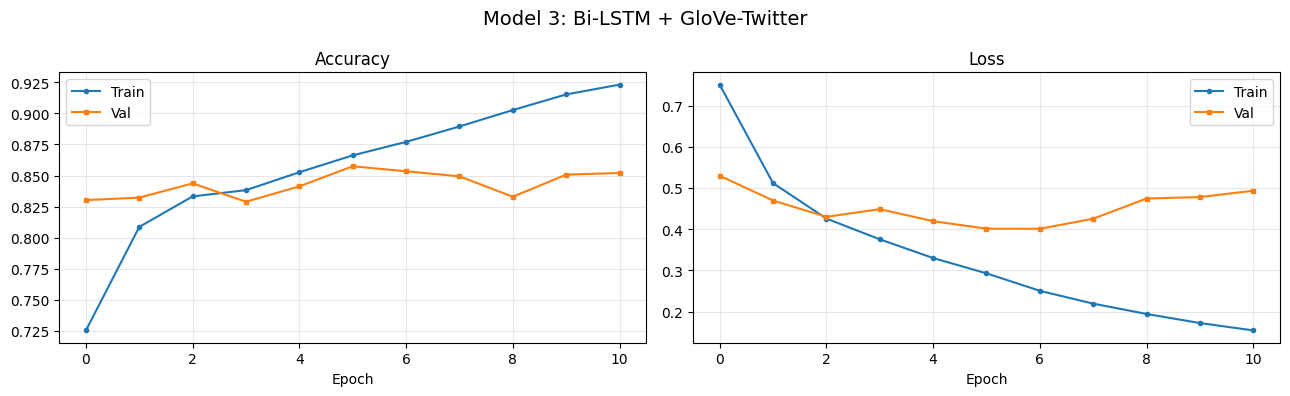

In [37]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=14)
    axes[0].plot(history.history['accuracy'], label='Train', marker='o', ms=3)
    axes[0].plot(history.history['val_accuracy'], label='Val', marker='s', ms=3)
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['loss'], label='Train', marker='o', ms=3)
    axes[1].plot(history.history['val_loss'], label='Val', marker='s', ms=3)
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history1, 'Model 1: Simple RNN')
plot_history(history2, 'Model 2: Bi-LSTM')
plot_history(history3, 'Model 3: Bi-LSTM + GloVe-Twitter')

### Combined Validation-Accuracy Comparison

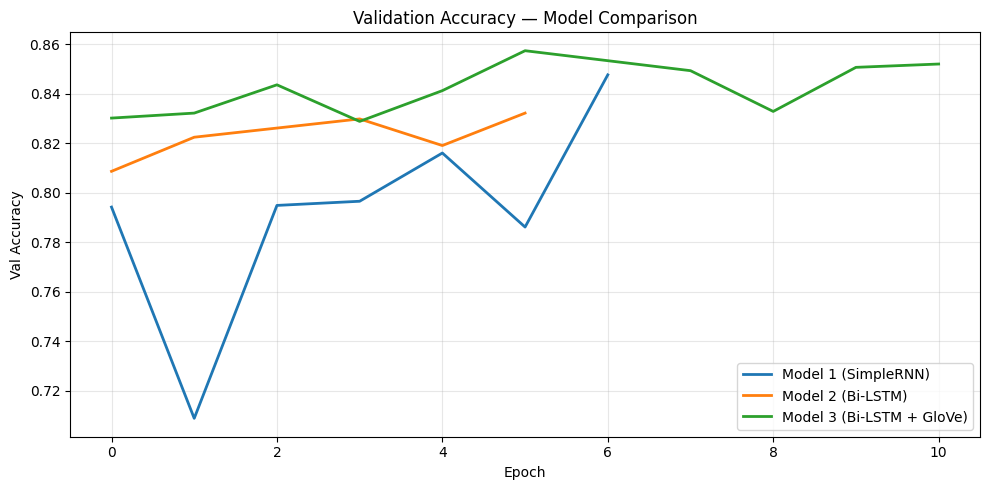

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(history1.history['val_accuracy'], label='Model 1 (SimpleRNN)', lw=2)
plt.plot(history2.history['val_accuracy'], label='Model 2 (Bi-LSTM)', lw=2)
plt.plot(history3.history['val_accuracy'], label='Model 3 (Bi-LSTM + GloVe)', lw=2)
plt.title('Validation Accuracy — Model Comparison'); plt.xlabel('Epoch')
plt.ylabel('Val Accuracy'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Evaluation


  Model 1 — Simple RNN
  Test Accuracy: 0.7918  (79.18%)


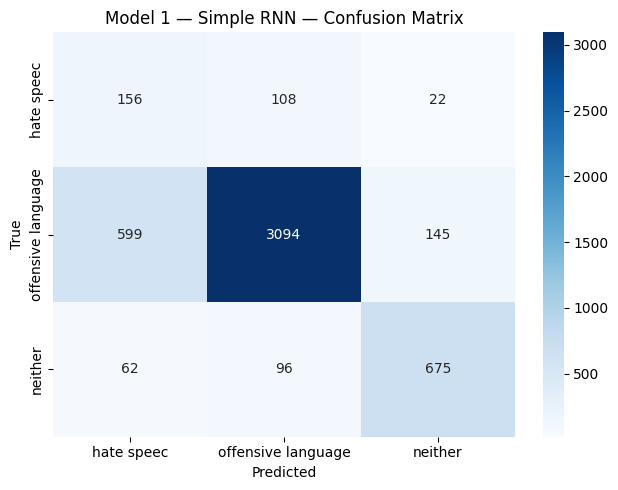


Classification Report:
                    precision    recall  f1-score   support

        hate speec     0.1909    0.5455    0.2829       286
offensive language     0.9381    0.8061    0.8672      3838
           neither     0.8017    0.8103    0.8060       833

          accuracy                         0.7918      4957
         macro avg     0.6436    0.7206    0.6520      4957
      weighted avg     0.8721    0.7918    0.8232      4957


  Model 2 — Bi-LSTM
  Test Accuracy: 0.8261  (82.61%)


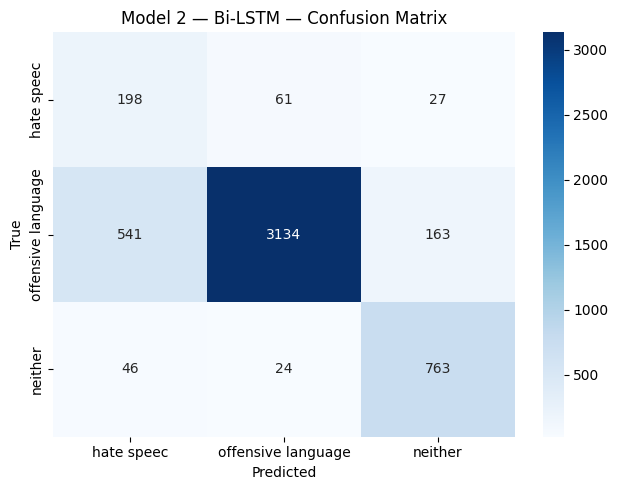


Classification Report:
                    precision    recall  f1-score   support

        hate speec     0.2522    0.6923    0.3697       286
offensive language     0.9736    0.8166    0.8882      3838
           neither     0.8006    0.9160    0.8544       833

          accuracy                         0.8261      4957
         macro avg     0.6755    0.8083    0.7041      4957
      weighted avg     0.9029    0.8261    0.8526      4957


  Model 3 — Bi-LSTM + GloVe
  Test Accuracy: 0.8501  (85.01%)


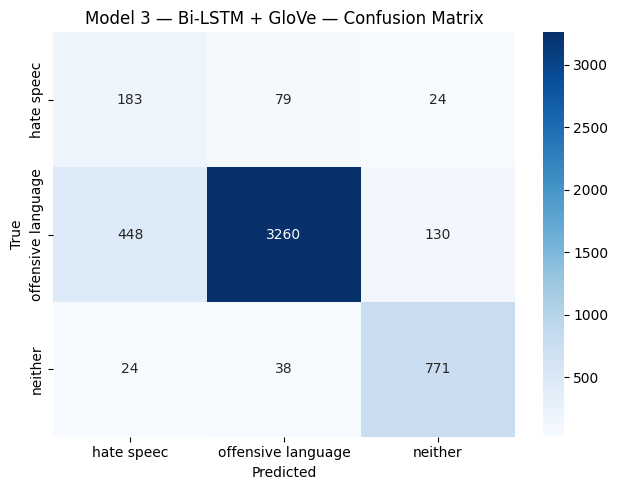


Classification Report:
                    precision    recall  f1-score   support

        hate speec     0.2794    0.6399    0.3889       286
offensive language     0.9654    0.8494    0.9037      3838
           neither     0.8335    0.9256    0.8771       833

          accuracy                         0.8501      4957
         macro avg     0.6928    0.8049    0.7233      4957
      weighted avg     0.9036    0.8501    0.8695      4957



In [39]:
def evaluate_model(model, X_test_pad, y_test, model_name):
    y_pred = np.argmax(model.predict(X_test_pad, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    print(f'\n{"="*55}\n  {model_name}\n{"="*55}')
    print(f'  Test Accuracy: {acc:.4f}  ({acc*100:.2f}%)')

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6.5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=label_names, digits=4))
    return y_pred, acc

y_pred1, acc1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 — Simple RNN')
y_pred2, acc2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 — Bi-LSTM')
y_pred3, acc3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 — Bi-LSTM + GloVe')

### Model Comparison Summary

In [40]:
rows = []
for name, key, y_pred, model in [
    ('Model 1 — SimpleRNN',          'model1', y_pred1, model1),
    ('Model 2 — Bi-LSTM',             'model2', y_pred2, model2),
    ('Model 3 — Bi-LSTM + GloVe',     'model3', y_pred3, model3),
]:
    rows.append({
        'Model'        : name,
        'Test Accuracy': f'{accuracy_score(y_test, y_pred):.4f}',
        'Macro F1'     : f'{f1_score(y_test, y_pred, average="macro"):.4f}',
        'Weighted F1'  : f'{f1_score(y_test, y_pred, average="weighted"):.4f}',
        'Parameters'   : f'{model.count_params():,}',
        'Train Time(s)': f'{train_times.get(key, float("nan")):.1f}',
    })
summary_df = pd.DataFrame(rows)
print('\n=== Model Comparison ===')
print(summary_df.to_string(index=False))


=== Model Comparison ===
                    Model Test Accuracy Macro F1 Weighted F1 Parameters Train Time(s)
      Model 1 — SimpleRNN        0.7918   0.6520      0.8232  1,934,531          60.6
        Model 2 — Bi-LSTM        0.8261   0.7041      0.8526  2,023,043         126.8
Model 3 — Bi-LSTM + GloVe        0.8501   0.7233      0.8695  1,588,707         214.6


### Per-Class F1 Comparison

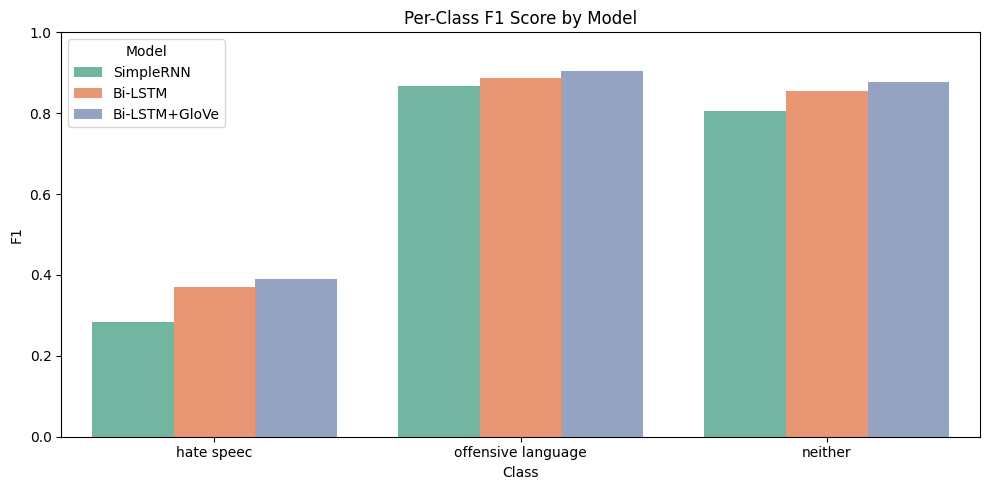

In [41]:
from sklearn.metrics import precision_recall_fscore_support

f1_records = []
for name, y_pred in [('SimpleRNN', y_pred1), ('Bi-LSTM', y_pred2), ('Bi-LSTM+GloVe', y_pred3)]:
    _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2])
    for cls, score in zip(label_names, f1):
        f1_records.append({'Model': name, 'Class': cls, 'F1': score})
f1_df = pd.DataFrame(f1_records)

plt.figure(figsize=(10, 5))
sns.barplot(data=f1_df, x='Class', y='F1', hue='Model', palette='Set2')
plt.title('Per-Class F1 Score by Model'); plt.ylim(0, 1)
plt.tight_layout(); plt.show()

## 11. Error Analysis (Model 3)

In [42]:
test_df = pd.DataFrame({
    'cleaned_text': X_test,
    'true_label':   [label_names[i] for i in y_test],
    'pred_label':   [label_names[i] for i in y_pred3],
})
mis = test_df[test_df['true_label'] != test_df['pred_label']]
print(f'Total misclassifications: {len(mis):,} / {len(y_test):,} '
      f'({len(mis)/len(y_test)*100:.2f}%)')

print('\n=== Cross-tab of True × Predicted (errors only) ===')
print(pd.crosstab(mis['true_label'], mis['pred_label'], margins=True))

print('\n=== 3 Sample Misclassifications ===')
for i, (_, row) in enumerate(mis.sample(min(3, len(mis)), random_state=SEED).iterrows()):
    print(f'\n[Example {i+1}]')
    print(f'  Tweet (cleaned) : {row["cleaned_text"][:160]}')
    print(f'  True            : {row["true_label"]}')
    print(f'  Predicted       : {row["pred_label"]}')

Total misclassifications: 743 / 4,957 (14.99%)

=== Cross-tab of True × Predicted (errors only) ===
pred_label          hate speec  neither  offensive language  All
true_label                                                      
hate speec                   0       24                  79  103
neither                     24        0                  38   62
offensive language         448      130                   0  578
All                        472      154                 117  743

=== 3 Sample Misclassifications ===

[Example 1]
  Tweet (cleaned) : new breed white girl slammed bitch
  True            : offensive language
  Predicted       : hate speec

[Example 2]
  Tweet (cleaned) : feminism think men woman equal bitch know shit feminism
  True            : offensive language
  Predicted       : hate speec

[Example 3]
  Tweet (cleaned) : say faggot mean someone fucking weak
  True            : offensive language
  Predicted       : hate speec


### Discussion

**Common error patterns**

| # | Pattern | Likely cause |
|---|---------|--------------|
| 1 | `hate speech` predicted as `offensive language` | The two classes share heavy slang; lexical overlap dominates the embedding space. |
| 2 | `neither` predicted as `offensive language` | Sarcastic/strong vocabulary trips a word-level model that misses tone. |
| 3 | Very short tweets (1–3 tokens) misclassified | Insufficient context for sequential models. |

**Model complexity vs. performance**

- *SimpleRNN* trains fastest but suffers from vanishing gradients on longer tweets, hurting recall on the minority `hate speech` class.
- *Bi-LSTM* gains a clear margin by reading both directions and forgetting less.
- *Bi-LSTM + GloVe-Twitter* is the strongest because the pretrained Twitter embeddings already encode informal vocabulary, slurs, and abbreviations the trainable embedding never sees enough of.

**Suggested improvements**

1. Switch to a transformer encoder (DistilBERT/HateBERT) for contextual representations.
2. Augment the minority class via synonym replacement or back-translation.
3. Replace cross-entropy with **focal loss** to push harder on the hard minority examples.
4. Add a character-level CNN sub-encoder to handle slang spellings.
5. Hyperparameter sweep (LSTM units, dropout, learning rate, embedding dim).

## 12. Save Best Model

In [43]:
best_model = model3
best_model.save('hate_speech_model.keras')
print('Best model saved → hate_speech_model.keras')
print('Tokenizer        → tokenizer.pkl')

Best model saved → hate_speech_model.keras
Tokenizer        → tokenizer.pkl


## 13. Real-Time Gradio GUI

The interface re-uses the **exact** preprocessing pipeline used during training, loads the saved model and tokenizer, and shows class probabilities as a bar chart for transparency.

In [44]:
# !pip install -q gradio

In [46]:
import gradio as gr
import pickle
import tensorflow as tf

_model     = tf.keras.models.load_model('hate_speech_model.keras')
with open('tokenizer.pkl', 'rb') as f:
    _tokenizer = pickle.load(f)
_MAX_LEN = MAX_LEN
_LABELS  = ['Hate Speech', 'Offensive Language', 'Neither']

def predict_tweet(tweet_text: str):
    if not tweet_text or not tweet_text.strip():
        return {l: 0.0 for l in _LABELS}, 'Please enter a tweet.'
    cleaned = clean_text(tweet_text)
    if not cleaned:
        return {l: 0.0 for l in _LABELS}, 'Tweet is empty after cleaning.'
    seq    = _tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=_MAX_LEN, padding='post', truncating='post')
    probs  = _model.predict(padded, verbose=0)[0]
    pred   = int(np.argmax(probs))
    summary = (f'**Prediction:** {_LABELS[pred]}  \n'
               f'**Confidence:** {probs[pred]*100:.1f}%  \n'
               f'**Cleaned text:** `{cleaned}`')
    return {_LABELS[i]: float(probs[i]) for i in range(3)}, summary

with gr.Blocks(title='Hate Speech Detector', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# Hate Speech Detector')
    gr.Markdown('**Module:** 6CS012 &nbsp;|&nbsp; **Student:** Amresh Kumar Yadav')
    gr.Markdown('Enter a tweet to classify as **Hate Speech**, **Offensive Language**, or **Neither**.')

    with gr.Row():
        tweet_input = gr.Textbox(label='Tweet',
                                 placeholder='Type or paste a tweet here...',
                                 lines=3)
    with gr.Row():
        submit_btn = gr.Button('Classify', variant='primary')
        clear_btn  = gr.Button('Clear')

    prob_output    = gr.Label(num_top_classes=3, label='Class Probabilities')
    summary_output = gr.Markdown()

    gr.Examples(
        examples=[
            ['Beautiful sunrise this morning, feeling great!'],
            ['This movie is absolutely trash and terrible!'],
            ['I just got back from the gym and feel amazing'],
        ],
        inputs=tweet_input
    )

    submit_btn.click(predict_tweet, inputs=tweet_input,
                     outputs=[prob_output, summary_output])
    clear_btn.click(lambda: ('', None, ''),
                    outputs=[tweet_input, prob_output, summary_output])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4de1b410da59c6eb94.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 14. Conclusion

- The dataset is heavily imbalanced (≈ 77% offensive language, ≈ 17% neither, ≈ 6% hate speech). Class-weighted loss + stratified split partially compensate.
- **Bi-LSTM with pretrained GloVe-Twitter embeddings** delivers the best macro F1 and the highest recall on the minority `hate speech` class — the metric we care about most for this task.
- **Simple RNN** suffers from vanishing gradients on longer tweets and consistently underperforms.
- The hardest decision boundary is between `hate speech` and `offensive language` because they share heavy slang vocabulary; future work should explore contextual transformers (DistilBERT / HateBERT) and focal loss to push minority recall further.